# NumberStateSource -> SpectralFilter example

This notebook shows a minimal symbolic workflow:

1. prepare a photon number state with `NumberStateSource`,
2. apply a `SpectralFilter`,
3. inspect the resulting state and mode labels.

The example is intentionally simple and is meant as a starting point for device-level tests and demos.


## Notes

- The import paths below follow the structure discussed in the implementation.
- If your local package layout differs slightly, adjust the imports in the first code cell.
- The notebook focuses on the semantic/device flow rather than plotting.


In [1]:
# Core device imports
from symop.devices.runtime import get_default_runtime
from symop.devices.models.filters import SpectralFilter
from symop.devices.models.sources.number_state_source import NumberStateSource

# State wrappers
from symop.polynomial.state.ket import KetPolyState

# Labels / envelopes / transfer functions
from symop.modes.labels.path import Path
from symop.modes.labels.polarization import Polarization
from symop.modes.envelopes import GaussianEnvelope

# Replace this import with your actual transfer-function implementation
# Example candidates could be GaussianLowpass, GaussianBandpass, etc.
from symop.modes.transfer import GaussianLowpass
import symop.viz as VI


## Build a one-photon source

The source emits a single mode on the `out` path with a chosen envelope and polarization.


LadderOp(kind=<OperatorKind.CRE: 'adag'>, mode=ModeOp(label=ModeLabel(path=Path(name='src_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=0.2, tau=0.0, phi0=0.0)), user_label=None, display_index=1))|0>

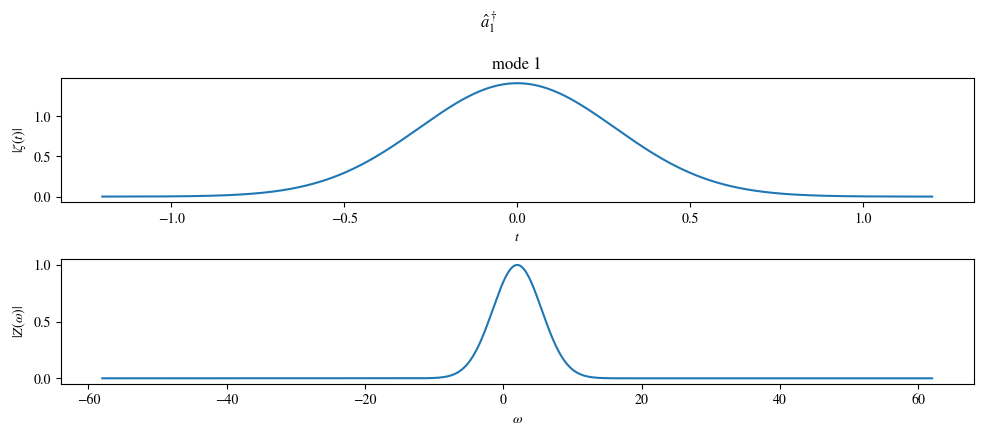

In [2]:
env = GaussianEnvelope(
    omega0=2.0,
    sigma=0.2,
    tau=0.0,
)

src = NumberStateSource(
    envelope=env,
    polarization=Polarization.H(),
    n=1,
)

vac = KetPolyState.vacuum()
rt = get_default_runtime()

psi_src = src.apply(
    vac,
    ports={"out": Path("src_out")},
    runtime=rt,
)


VI.plot(psi_src)
VI.display(psi_src)

## Inspect source modes


In [3]:
psi_src.modes

(ModeOp(label=ModeLabel(path=Path(name='src_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=0.2, tau=0.0, phi0=0.0)), user_label=None, display_index=1),)

In [4]:
psi_src.mode_labels

{('mode',
  ('mode_label',
   ('path', 'src_out'),
   ('pol', 1.0, 0.0, 0.0, 0.0),
   ('gauss',
    2.0,
    0.2,
    0.0,
    0.0))): ModeLabel(path=Path(name='src_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=0.2, tau=0.0, phi0=0.0))}

## Define a spectral filter

Here we use a Gaussian low-pass style transfer function as an example. Adjust the constructor to match your concrete implementation.


0.971727 * 0.971727 · I · (.) · I + 0.028273 * 0.028273 · LadderOp(kind=<OperatorKind.CRE: 'adag'>, mode=ModeOp(label=ModeLabel(path=Path(name='filtered_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=7.073895673530957, tau=0.0, phi0=0.0)), user_label=None, display_index=1)) · (.) · LadderOp(kind=<OperatorKind.CRE: 'adag'>, mode=ModeOp(label=ModeLabel(path=Path(name='filtered_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=7.073895673530957, tau=0.0, phi0=0.0)), user_label=None, display_index=1))

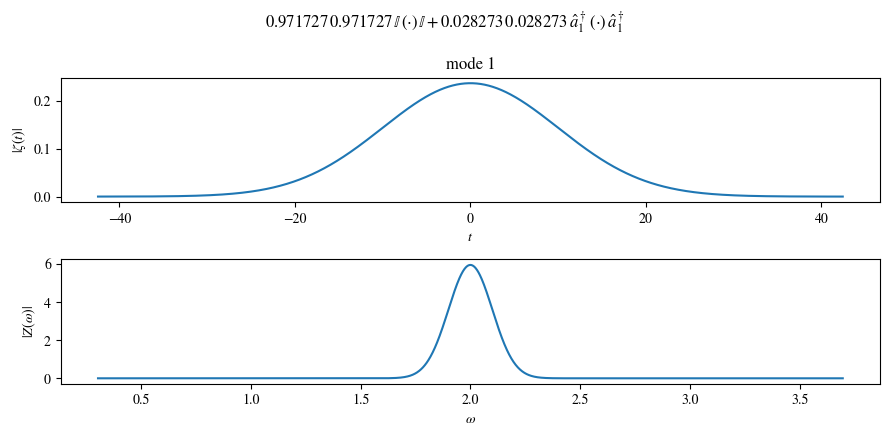

In [5]:
filt = SpectralFilter(
    transfer=GaussianLowpass(
        w0=2.0,
        sigma_w=0.1,
    )
)
psi_filt = filt(
    psi_src,
    ports={"in": Path("src_out"), "out": Path("filtered_out")},
    runtime=rt,
)

VI.plot(psi_filt)
VI.display(psi_filt)

## Inspect the filtered state

You should see that the mode label has moved from `src_out` to `filtered_out`, and that the envelope stored in the label has been updated according to the transfer function.


In [6]:
psi_filt.modes

(ModeOp(label=ModeLabel(path=Path(name='filtered_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=7.073895673530957, tau=0.0, phi0=0.0)), user_label=None, display_index=1),)

In [7]:
psi_filt.mode_labels

{('mode',
  ('mode_label',
   ('path', 'filtered_out'),
   ('pol', 1.0, 0.0, 0.0, 0.0),
   ('gauss',
    2.0,
    7.073895673530957,
    0.0,
    0.0))): ModeLabel(path=Path(name='filtered_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=7.073895673530957, tau=0.0, phi0=0.0))}

In [8]:
for sig, label in psi_filt.mode_labels.items():
    print('signature:', sig)
    print('path:', label.path)
    print('polarization:', label.polarization)
    print('envelope:', label.envelope)
    print()

signature: ('mode', ('mode_label', ('path', 'filtered_out'), ('pol', 1.0, 0.0, 0.0, 0.0), ('gauss', 2.0, 7.073895673530957, 0.0, 0.0)))
path: Path(name='filtered_out')
polarization: Polarization(jones=((1+0j), 0j))
envelope: GaussianEnvelope(omega0=2.0, sigma=7.073895673530957, tau=0.0, phi0=0.0)



## Compare source and filtered paths


In [9]:
print('Source paths:')
for mode in psi_src.modes:
    print(mode.label.path)

print('\nFiltered paths:')
for mode in psi_filt.modes:
    print(mode.label.path)


Source paths:
Path(name='src_out')

Filtered paths:
Path(name='filtered_out')


## Optional: density-state version

If you have registered the density kernel for the source and filter, you can convert to density and repeat the same workflow.


In [10]:
rho_src = psi_src.to_density()
rho_filt = filt.apply(
    rho_src,
    ports={"in": Path("src_out"), "out": Path("filtered_rho_out")},
    runtime=rt,
)

rho_filt

DensityPolyState(rho=DensityPoly(terms=(DensityTerm(coeff=(0.9717270356773343+0j), left=Monomial(creators=(), annihilators=()), right=Monomial(creators=(), annihilators=())), DensityTerm(coeff=(0.028272964322665708+0j), left=Monomial(creators=(LadderOp(kind=<OperatorKind.CRE: 'adag'>, mode=ModeOp(label=ModeLabel(path=Path(name='filtered_rho_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=7.073895673530957, tau=0.0, phi0=0.0)), user_label=None, display_index=1)),), annihilators=()), right=Monomial(creators=(LadderOp(kind=<OperatorKind.CRE: 'adag'>, mode=ModeOp(label=ModeLabel(path=Path(name='filtered_rho_out'), polarization=Polarization(jones=((1+0j), 0j)), envelope=GaussianEnvelope(omega0=2.0, sigma=7.073895673530957, tau=0.0, phi0=0.0)), user_label=None, display_index=1)),), annihilators=())))), label=None, index=4)

## Suggested next extensions

- emit `n > 1` photons,
- compare different transfer functions,
- inspect density-state attenuation,
- add a measurement notebook once photon counting is implemented.
